In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("../data/results_clean.csv")
print(df.shape)
print(df.dtypes)
print(df.head(3).to_string())

(49476, 11)
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
year            int64
decade          int64
dtype: object
         date home_team away_team  home_score  away_score tournament     city   country  neutral  year  decade
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow  Scotland    False  1872    1870
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   England    False  1873    1870
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow  Scotland    False  1874    1870


In [2]:

df = pd.read_csv("../data/results_clean.csv")
df_ranking = pd.read_csv("../data/fifa_ranking.csv")

# --- 1. Normalizar nomes para merge (lowercase, sem espaços extra) ---
df_ranking["name_norm"] = df_ranking["country_name"].str.strip().str.lower()
df["home_norm"] = df["home_team"].str.strip().str.lower()
df["away_norm"] = df["away_team"].str.strip().str.lower()

# --- 2. Merge ranking para home e away ---
rank_lookup = df_ranking[["name_norm", "ranking"]].rename(columns={"ranking": "rank_home"})
df = df.merge(rank_lookup, left_on="home_norm", right_on="name_norm", how="left").drop(columns="name_norm")

rank_lookup = df_ranking[["name_norm", "ranking"]].rename(columns={"ranking": "rank_away"})
df = df.merge(rank_lookup, left_on="away_norm", right_on="name_norm", how="left").drop(columns="name_norm")

# --- 3. Diff_Ranking (home - away): valor positivo = away é melhor ranked ---
df["Diff_Ranking"] = df["rank_home"] - df["rank_away"]

# --- 4. Diagnóstico: equipas sem match no ranking ---
unmatched_home = df[df["rank_home"].isna()]["home_team"].unique()
unmatched_away = df[df["rank_away"].isna()]["away_team"].unique()
unmatched = sorted(set(unmatched_home) | set(unmatched_away))

print(f"Equipas sem match no ranking FIFA: {len(unmatched)}")
print(unmatched[:30])  # primeiras 30

Equipas sem match no ranking FIFA: 142
['Abkhazia', 'Alderney', 'Ambazonia', 'Andalusia', 'Arameans Suryoye', 'Artsakh', 'Asturias', 'Aymara', 'Barawa', 'Basque Country', 'Biafra', 'Bonaire', 'Brittany', 'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia', 'Central Spain', 'Chagos Islands', 'Chameria', 'Chechnya', 'China', 'Cilento', 'Corsica', 'County of Nice', 'Crimea', 'Czech Republic', 'Czechoslovakia', 'DR Congo', 'Darfur']


In [3]:
# Ver os 142 todos + cruzar com nomes do ranking para identificar mismatches reais
print("LISTA COMPLETA:")
print(unmatched)

# Quantos jogos recentes (pós-2000) têm estas equipas? 
# Se for muitos, são mismatches relevantes. Se forem poucos, são territórios irrelevantes.
df["date"] = pd.to_datetime(df["date"])
recent = df[df["date"] >= "2000-01-01"]

unmatched_set = set(unmatched)
affected = recent[
    recent["home_team"].isin(unmatched_set) | recent["away_team"].isin(unmatched_set)
]

print(f"\nJogos pós-2000 afetados: {len(affected)}")
print(affected["home_team"].where(affected["home_team"].isin(unmatched_set))
      .combine_first(affected["away_team"].where(affected["away_team"].isin(unmatched_set)))
      .value_counts().head(20))

LISTA COMPLETA:
['Abkhazia', 'Alderney', 'Ambazonia', 'Andalusia', 'Arameans Suryoye', 'Artsakh', 'Asturias', 'Aymara', 'Barawa', 'Basque Country', 'Biafra', 'Bonaire', 'Brittany', 'Canary Islands', 'Cape Verde', 'Cascadia', 'Catalonia', 'Central Spain', 'Chagos Islands', 'Chameria', 'Chechnya', 'China', 'Cilento', 'Corsica', 'County of Nice', 'Crimea', 'Czech Republic', 'Czechoslovakia', 'DR Congo', 'Darfur', 'Donetsk PR', 'Délvidék', 'East Turkestan', 'Elba Island', 'Ellan Vannin', 'Falkland Islands', 'Felvidék', 'Franconia', 'French Guiana', 'Frøya', 'Galicia', 'Gambia', 'German DR', 'Gotland', 'Gozo', 'Greenland', 'Guadeloupe', 'Guernsey', 'Găgăuzia', 'Hitra', 'Hmong', 'Iran', 'Iraqi Kurdistan', 'Isle of Man', 'Isle of Wight', 'Ivory Coast', 'Jersey', 'Kabylia', 'Kernow', 'Kiribati', 'Kurdistan', 'Kyrgyzstan', 'Kárpátalja', 'Luhansk PR', 'Madrid', 'Manchukuo', 'Mapuche', 'Marshall Islands', 'Martinique', 'Matabeleland', 'Maule Sur', 'Mayotte', 'Menorca', 'Micronesia', 'Monaco', 'Ni

In [4]:
# Ver nomes exatos que a FIFA usa no ranking
ranking_names = set(df_ranking["country_name"].str.strip().str.lower())

# Candidatos a mismatch: equipas com >50 jogos pós-2000 que não matcharam
high_volume = (
    affected["home_team"]
    .where(affected["home_team"].isin(unmatched_set))
    .combine_first(affected["away_team"].where(affected["away_team"].isin(unmatched_set)))
    .value_counts()
)
high_volume = high_volume[high_volume > 50].index.tolist()

print("Candidatos a mismatch (>50 jogos pós-2000):")
for team in sorted(high_volume):
    print(f"  '{team}'")

print("\nNomes FIFA disponíveis que podem corresponder:")
keywords = ["korea", "iran", "china", "turkey", "ivory", "congo", "czech", 
            "cape", "gambia", "taiwan", "united states", "kyrgyz", "saint"]
for kw in keywords:
    matches = [n for n in df_ranking["country_name"] if kw.lower() in n.lower()]
    if matches:
        print(f"  '{kw}' → {matches}")

Candidatos a mismatch (>50 jogos pós-2000):
  'Cape Verde'
  'China'
  'Czech Republic'
  'DR Congo'
  'French Guiana'
  'Gambia'
  'Guadeloupe'
  'Iran'
  'Ivory Coast'
  'Kyrgyzstan'
  'Martinique'
  'North Korea'
  'Saint Kitts and Nevis'
  'Saint Lucia'
  'Saint Vincent and the Grenadines'
  'South Korea'
  'Taiwan'
  'Turkey'
  'United States'
  'United States Virgin Islands'
  'Zanzibar'

Nomes FIFA disponíveis que podem corresponder:
  'korea' → ['Korea Republic', 'DPR Korea']
  'iran' → ['IR Iran']
  'china' → ['China PR']
  'congo' → ['Congo DR', 'Congo']
  'czech' → ['Czechia']
  'gambia' → ['The Gambia']
  'kyrgyz' → ['Kyrgyz Republic']


In [5]:
# --- Verificar os 5 nomes incertos contra o ranking real ---
check = ["cape verde", "ivory coast", "turkey", "united states", "taiwan"]
for kw in check:
    matches = [n for n in df_ranking["country_name"] if kw.lower() in n.lower()]
    print(f"'{kw}' → {matches if matches else 'SEM MATCH'}")

'cape verde' → SEM MATCH
'ivory coast' → SEM MATCH
'turkey' → SEM MATCH
'united states' → SEM MATCH
'taiwan' → SEM MATCH


In [6]:
# Imprimir todos os 211 nomes do ranking para identificar manualmente
for name in sorted(df_ranking["country_name"].tolist()):
    print(name)

Afghanistan
Albania
Algeria
American Samoa
Andorra
Angola
Anguilla
Antigua and Barbuda
Argentina
Armenia
Aruba
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
British Virgin Islands
Brunei
Bulgaria
Burkina Faso
Burundi
Cabo Verde
Cambodia
Cameroon
Canada
Cayman Islands
Central African Republic
Chad
Chile
China PR
Chinese Taipei
Colombia
Comoros
Congo
Congo DR
Cook Islands
Costa Rica
Croatia
Cuba
Curaçao
Cyprus
Czechia
Côte d'Ivoire
DPR Korea
Denmark
Djibouti
Dominica
Dominican Republic
Ecuador
Egypt
El Salvador
England
Equatorial Guinea
Eritrea
Estonia
Eswatini
Ethiopia
Faroe Islands
Fiji
Finland
France
Gabon
Georgia
Germany
Ghana
Gibraltar
Greece
Grenada
Guam
Guatemala
Guinea
Guinea-Bissau
Guyana
Haiti
Honduras
Hong Kong
Hungary
IR Iran
Iceland
India
Indonesia
Iraq
Israel
Italy
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Korea Republic
Kosovo
Kuwait
Kyrgyz Republic
Laos
Latvia
Lebanon

In [7]:
NAME_MAP = {
    # Confirmados anteriormente
    "south korea":                      "korea republic",
    "north korea":                      "dpr korea",
    "iran":                             "ir iran",
    "china":                            "china pr",
    "dr congo":                         "congo dr",
    "czech republic":                   "czechia",
    "gambia":                           "the gambia",
    "kyrgyzstan":                       "kyrgyz republic",
    # Os 5 que faltavam
    "cape verde":                       "cabo verde",
    "ivory coast":                      "côte d'ivoire",
    "turkey":                           "türkiye",
    "united states":                    "usa",
    "taiwan":                           "chinese taipei",
    # Estes afinal também são FIFA (nomes truncados)
    "saint kitts and nevis":            "st. kitts and nevis",
    "saint lucia":                      "st. lucia",
    "saint vincent and the grenadines": "st. vincent / grenadines",
    "united states virgin islands":     "us virgin islands",
}

In [8]:
# --- Aplicar mapeamento e fazer merge ---
df_ranking["name_norm"] = df_ranking["country_name"].str.strip().str.lower()

def normalize(name: str) -> str:
    n = name.strip().lower()
    return NAME_MAP.get(n, n)

df["home_norm"] = df["home_team"].apply(normalize)
df["away_norm"] = df["away_team"].apply(normalize)

rank_lookup_full = df_ranking[["name_norm", "ranking", "points"]].set_index("name_norm")

df["rank_home"]   = df["home_norm"].map(rank_lookup_full["ranking"])
df["rank_away"]   = df["away_norm"].map(rank_lookup_full["ranking"])
df["points_home"] = df["home_norm"].map(rank_lookup_full["points"])
df["points_away"] = df["away_norm"].map(rank_lookup_full["points"])

df["Diff_Ranking"] = df["rank_home"] - df["rank_away"]
df["Diff_Points"]  = df["points_home"] - df["points_away"]

# --- Validação final ---
still_unmatched = df[df["rank_home"].isna() | df["rank_away"].isna()]
real_teams_unmatched = (
    still_unmatched[["home_team", "away_team"]]
    .melt(value_name="team")["team"]
    .value_counts()
)

print(real_teams_unmatched[real_teams_unmatched > 50])
print(f"\nNaN em rank_home:    {df['rank_home'].isna().sum()}")
print(f"NaN em rank_away:    {df['rank_away'].isna().sum()}")
print(f"NaN em Diff_Points:  {df['Diff_Points'].isna().sum()}")

print(f"\nDescritive Diff_Points:")
print(df["Diff_Points"].describe().round(2))

print(f"\nAmostra com Diff_Ranking e Diff_Points preenchidos:")
print(df[df["Diff_Points"].notna()][
    ["home_team", "away_team", "rank_home", "rank_away", "Diff_Ranking", "Diff_Points"]
].head(5).to_string())

team
Czechoslovakia         520
Yugoslavia             483
Martinique             331
German DR              298
Guadeloupe             271
Guernsey               240
Jersey                 235
Zanzibar               209
Vietnam Republic       195
French Guiana          179
Alderney               135
Réunion                124
Hungary                 89
Romania                 84
Suriname                83
Greenland               77
Saint Martin            68
Ynys Môn                67
Basque Country          64
Bulgaria                62
Austria                 61
Poland                  60
Sint Maarten            60
Shetland                58
Isle of Man             58
France                  56
Trinidad and Tobago     55
Åland Islands           51
Gibraltar               51
Name: count, dtype: int64

NaN em rank_home:    2389
NaN em rank_away:    2791
NaN em Diff_Points:  3999

Descritive Diff_Points:
count    45477.00
mean        16.65
std        273.29
min      -1143.12
25%       

Inglaterra (#4) vs Escócia (#41) → Diff_Points = +343 (Inglaterra muito melhor em pontos)

Escócia vs Inglaterra → Diff_Points = -343 (simétrico, correcto)

Range: -1143 a +1143 — amplitude muito maior que Diff_Ranking (-208 a +208)

O Diff_Points é mais informativo — reflecte a distância real entre equipas, não apenas posições ordinais.

Hungary, Romania, Austria, France, etc. na lista de unmatched — é o mesmo problema de diagnóstico que já vimos antes. São jogos onde o adversário é território não-FIFA, não um problema com essas selecções.

In [9]:
# # --- Aplicar mapeamento e fazer merge ---
# df_ranking["name_norm"] = df_ranking["country_name"].str.strip().str.lower()

# def normalize(name: str) -> str:
#     n = name.strip().lower()
#     return NAME_MAP.get(n, n)

# df["home_norm"] = df["home_team"].apply(normalize)
# df["away_norm"] = df["away_team"].apply(normalize)

# rank_lookup = df_ranking[["name_norm", "ranking"]].set_index("name_norm")["ranking"]

# df["rank_home"] = df["home_norm"].map(rank_lookup)
# df["rank_away"] = df["away_norm"].map(rank_lookup)
# df["Diff_Ranking"] = df["rank_home"] - df["rank_away"]

# # --- Validação final ---
# still_unmatched = df[df["rank_home"].isna() | df["rank_away"].isna()]
# real_teams_unmatched = (
#     still_unmatched[["home_team", "away_team"]]
#     .melt(value_name="team")["team"]
#     .value_counts()
# )

# # Filtrar só os que têm >50 jogos (os territórios não-FIFA são ruído aceitável)
# print(real_teams_unmatched[real_teams_unmatched > 50])
# print(f"\nNaN em rank_home: {df['rank_home'].isna().sum()}")
# print(f"NaN em rank_away: {df['rank_away'].isna().sum()}")
# print(f"\nAmostra com Diff_Ranking preenchido:")
# print(df[df["Diff_Ranking"].notna()][["home_team", "away_team", "rank_home", "rank_away", "Diff_Ranking"]].head(5))

In [10]:
# Ver a representação exata dos bytes para um caso suspeito
sample = df[df["home_team"].str.contains("Hungary", na=False)]["home_norm"].iloc[0]
print("home_norm repr:", repr(sample))

# Ver o que está no índice do rank_lookup para hungary
matches = [k for k in rank_lookup_full.index if "hungary" in k]
print("rank_lookup match:", matches)

# Fazer o mesmo para France (caso mais estranho)
sample2 = df[df["home_team"].str.contains("France", na=False)]["home_norm"].iloc[0]
print("france home_norm repr:", repr(sample2))
matches2 = [k for k in rank_lookup_full.index if "france" in k]
print("rank_lookup france match:", matches2)

home_norm repr: 'hungary'
rank_lookup match: ['hungary']
france home_norm repr: 'france'
rank_lookup france match: ['france']


In [11]:
# Contar NaN apenas no lado correto de cada equipa
unmatched_home = (
    df[df["rank_home"].isna()]["home_team"]
    .value_counts()
)
unmatched_away = (
    df[df["rank_away"].isna()]["away_team"]
    .value_counts()
)

# Combinar e somar ocorrências reais por equipa
real_unmatched = (
    unmatched_home.add(unmatched_away, fill_value=0)
    .astype(int)
    .sort_values(ascending=False)
)

print(real_unmatched[real_unmatched > 50])

home_team
Czechoslovakia      520
Yugoslavia          483
Martinique          331
German DR           298
Guadeloupe          271
Guernsey            240
Jersey              235
Zanzibar            209
Vietnam Republic    195
French Guiana       179
Alderney            135
Réunion             124
Greenland            77
Saint Martin         68
Ynys Môn             67
Basque Country       64
Sint Maarten         60
Shetland             58
Isle of Man          58
Åland Islands        51
Name: count, dtype: int64


## Fator casa

In [12]:
# --- Fator_Casa ---
def calc_fator_casa(row):
    if row["neutral"]:
        return 0
    country = row["country"].strip().lower()
    home    = row["home_team"].strip().lower()
    away    = row["away_team"].strip().lower()
    if country == home:
        return 1
    if country == away:
        return -1
    return 0

df["Fator_Casa"] = df.apply(calc_fator_casa, axis=1)

# --- Validação ---
print(df["Fator_Casa"].value_counts())
print(f"\nneutral=True com Fator_Casa != 0: {((df['neutral']) & (df['Fator_Casa'] != 0)).sum()}")

print("\nAmostra Fator_Casa=1:")
print(df[df["Fator_Casa"] == 1][["home_team","away_team","country","neutral","Fator_Casa"]].head(5).to_string())

print("\nAmostra Fator_Casa=-1:")
print(df[df["Fator_Casa"] == -1][["home_team","away_team","country","neutral","Fator_Casa"]].head(5).to_string())

Fator_Casa
 1    35379
 0    14089
-1        8
Name: count, dtype: int64

neutral=True com Fator_Casa != 0: 0

Amostra Fator_Casa=1:
  home_team away_team   country  neutral  Fator_Casa
0  Scotland   England  Scotland    False           1
1   England  Scotland   England    False           1
2  Scotland   England  Scotland    False           1
3   England  Scotland   England    False           1
4  Scotland   England  Scotland    False           1

Amostra Fator_Casa=-1:
      home_team away_team country  neutral  Fator_Casa
884   Catalonia     Spain   Spain    False          -1
1801    Silesia    Poland  Poland    False          -1
1833  Catalonia     Spain   Spain    False          -1
3010  Catalonia     Spain   Spain    False          -1
3761    Silesia    Poland  Poland    False          -1


A distribuição é correta — na grande maioria dos registos históricos, a equipa da casa é genuinamente a equipa do país anfitrião. O -1 é estruturalmente raro porque em football data a equipa anfitriã é quase sempre listada como home_team

In [13]:
print(df["tournament"].value_counts().to_string())

tournament
Friendly                                                    18387
FIFA World Cup qualification                                 8771
UEFA Euro qualification                                      2824
African Cup of Nations qualification                         2327
FIFA World Cup                                               1036
Copa América                                                  869
African Cup of Nations                                        845
AFC Asian Cup qualification                                   829
UEFA Nations League                                           658
CECAFA Cup                                                    620
CFU Caribbean Cup qualification                               606
Merdeka Tournament                                            599
British Home Championship                                     523
CONCACAF Nations League                                       422
AFC Asian Cup                                                 421

In [14]:
# --- Tipo_Competicao ---
def map_tipo_competicao(tournament: str) -> str:
    t = tournament.strip().lower()

    if t == "fifa world cup":
        return "Mundial"

    if "qualification" in t:
        return "Qualificacao"

    CONTINENTAL = {
        "uefa euro",
        "copa américa",
        "african cup of nations",
        "afc asian cup",
        "gold cup",
        "uefa nations league",
        "concacaf nations league",
        "concacaf championship",
        "oceania nations cup",
        "eaff championship",
        "aff championship",
        "waff championship",
        "saff cup",
        "cafa nations cup",
        "cosafa cup",
        "cecafa cup",
        "cfu caribbean cup",
        "confederations cup",
        "copa america",
        "nafu championship",
        "nafc championship",
        "conmebol–uefa cup of champions",
    }

    if t in CONTINENTAL:
        return "Torneio_Continental"

    return "Amigavel"

df["Tipo_Competicao"] = df["tournament"].apply(map_tipo_competicao)

# --- Validação ---
print(df["Tipo_Competicao"].value_counts())
print("\nVerificação Mundial:")
print(df[df["Tipo_Competicao"] == "Mundial"]["tournament"].value_counts())
print("\nVerificação Torneio_Continental (amostra):")
print(df[df["Tipo_Competicao"] == "Torneio_Continental"]["tournament"].value_counts().head(15))
print("\nVerificação Qualificacao (amostra):")
print(df[df["Tipo_Competicao"] == "Qualificacao"]["tournament"].value_counts().head(10))

Tipo_Competicao
Amigavel               26096
Qualificacao           15928
Torneio_Continental     6416
Mundial                 1036
Name: count, dtype: int64

Verificação Mundial:
tournament
FIFA World Cup    1036
Name: count, dtype: int64

Verificação Torneio_Continental (amostra):
tournament
Copa América               869
African Cup of Nations     845
UEFA Nations League        658
CECAFA Cup                 620
CONCACAF Nations League    422
AFC Asian Cup              421
Gold Cup                   420
UEFA Euro                  388
COSAFA Cup                 354
AFF Championship           291
CFU Caribbean Cup          251
CONCACAF Championship      169
SAFF Cup                   162
Confederations Cup         140
Oceania Nations Cup        139
Name: count, dtype: int64

Verificação Qualificacao (amostra):
tournament
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
AFC Asian Cup qualification 

In [ ]:

df["date"] = pd.to_datetime(df["date"])

# --- Construir formato longo: uma linha por equipa por jogo ---
df_played = df[df["home_score"].notna()].copy()

# Lado Home
home = df_played[["date", "home_team", "home_score", "away_score"]].copy()
home.columns = ["date", "team", "golos_marcados", "golos_sofridos"]
home["pontos"] = np.where(
    home["golos_marcados"] > home["golos_sofridos"], 3,
    np.where(home["golos_marcados"] == home["golos_sofridos"], 1, 0)
)

# Lado Away
away = df_played[["date", "away_team", "away_score", "home_score"]].copy()
away.columns = ["date", "team", "golos_marcados", "golos_sofridos"]
away["pontos"] = np.where(
    away["golos_marcados"] > away["golos_sofridos"], 3,
    np.where(away["golos_marcados"] == away["golos_sofridos"], 1, 0)
)

# Juntar e ordenar cronologicamente por equipa
df_long = pd.concat([home, away], ignore_index=True).sort_values(["team", "date"])

# Rolling mean dos últimos 10 jogos (shift=1 para evitar data leakage)
df_long["Forma_Golos"] = (
    df_long.groupby("team")["golos_marcados"]
    .transform(lambda x: x.shift(1).rolling(window=10, min_periods=1).mean())
)
df_long["Forma_Pts"] = (
    df_long.groupby("team")["pontos"]
    .transform(lambda x: x.shift(1).rolling(window=10, min_periods=1).mean())
)

print(f"df_long construído: {df_long.shape}")
print(df_long.head(3).to_string())

df_long construído: (98864, 7)
            date      team  golos_marcados  golos_sofridos  pontos  Forma_Golos  Forma_Pts
36260 2012-09-25  Abkhazia             1.0             1.0       1          NaN        NaN
85836 2012-10-21  Abkhazia             0.0             3.0       0          1.0        1.0
37317 2013-09-23  Abkhazia             3.0             0.0       3          0.5        0.5


In [16]:

df_long["Forma_Golos_Sofridos"] = (
    df_long.groupby("team")["golos_sofridos"]
    .transform(lambda x: x.shift(1).rolling(window=10, min_periods=1).mean())
)

print("Forma_Golos_Sofridos — amostra:")
print(df_long[df_long["Forma_Golos_Sofridos"].notna()][["team","date","golos_sofridos","Forma_Golos_Sofridos"]].head(5).to_string())

Forma_Golos_Sofridos — amostra:
           team       date  golos_sofridos  Forma_Golos_Sofridos
85836  Abkhazia 2012-10-21             3.0              1.000000
37317  Abkhazia 2013-09-23             0.0              2.000000
37791  Abkhazia 2014-06-01             1.0              1.333333
87228  Abkhazia 2014-06-02             1.0              1.250000
37823  Abkhazia 2014-06-04             0.0              1.200000


## Features forma (home e away - golos e vitórias)

In [17]:
# --- 4. Merge de volta ao df principal (substitui o bloco do .map()) ---
forma_home = df_long[["date", "team", "Forma_Golos", "Forma_Pts", "Forma_Golos_Sofridos"]].rename(columns={
    "team":                 "home_team",
    "Forma_Golos":          "Forma_Golos_Home",
    "Forma_Pts":            "Forma_Pts_Home",
    "Forma_Golos_Sofridos": "Forma_Golos_Sofridos_Home",
})
forma_away = df_long[["date", "team", "Forma_Golos", "Forma_Pts", "Forma_Golos_Sofridos"]].rename(columns={
    "team":                 "away_team",
    "Forma_Golos":          "Forma_Golos_Away",
    "Forma_Pts":            "Forma_Pts_Away",
    "Forma_Golos_Sofridos": "Forma_Golos_Sofridos_Away",
})

df = df.merge(forma_home, on=["date", "home_team"], how="left")
df = df.merge(forma_away, on=["date", "away_team"], how="left")

# --- 5. Validação ---
print("NaN por coluna de forma:")
for col in ["Forma_Golos_Home", "Forma_Pts_Home", "Forma_Golos_Away", "Forma_Pts_Away"]:
    print(f"  {col}: {df[col].isna().sum()}")

print("\nAmostra (jogos recentes com tudo preenchido):")
sample_cols = ["date", "home_team", "away_team",
               "Forma_Golos_Home", "Forma_Pts_Home",
               "Forma_Golos_Away", "Forma_Pts_Away"]
print(df[df["Forma_Golos_Home"].notna()][sample_cols].tail(5).to_string())

NaN por coluna de forma:
  Forma_Golos_Home: 185
  Forma_Pts_Home: 185
  Forma_Golos_Away: 239
  Forma_Pts_Away: 239

Amostra (jogos recentes com tudo preenchido):
            date       home_team               away_team  Forma_Golos_Home  Forma_Pts_Home  Forma_Golos_Away  Forma_Pts_Away
49763 2026-06-17           Ghana                  Panama               1.1             1.1               1.8             1.6
49764 2026-06-18  Czech Republic            South Africa               2.1             1.6               1.2             1.4
49765 2026-06-18          Mexico             South Korea               1.8             2.3               1.5             1.9
49766 2026-06-18     Switzerland  Bosnia and Herzegovina               1.9             1.7               1.5             1.3
49767 2026-06-18          Canada                   Qatar               0.9             1.5               0.6             0.7


In [18]:
print("NaN Forma_Golos_Sofridos_Home:", df["Forma_Golos_Sofridos_Home"].isna().sum())
print("NaN Forma_Golos_Sofridos_Away:", df["Forma_Golos_Sofridos_Away"].isna().sum())
print("\nAmostra:")
print(df[df["Forma_Golos_Sofridos_Home"].notna()][
    ["home_team","away_team","Forma_Golos_Home","Forma_Golos_Sofridos_Home",
     "Forma_Golos_Away","Forma_Golos_Sofridos_Away"]
].tail(5).to_string())

NaN Forma_Golos_Sofridos_Home: 185
NaN Forma_Golos_Sofridos_Away: 239

Amostra:
            home_team               away_team  Forma_Golos_Home  Forma_Golos_Sofridos_Home  Forma_Golos_Away  Forma_Golos_Sofridos_Away
49763           Ghana                  Panama               1.1                        1.4               1.8                        1.6
49764  Czech Republic            South Africa               2.1                        1.1               1.2                        1.2
49765          Mexico             South Korea               1.8                        0.4               1.5                        1.3
49766     Switzerland  Bosnia and Herzegovina               1.9                        0.9               1.5                        1.1
49767          Canada                   Qatar               0.9                        0.5               0.6                        1.4


In [19]:
# --- Dataset final de treino ---
WORLD_CUP_2026_START = "2026-06-11"

df["date"] = pd.to_datetime(df["date"])

# Criar target de classificação
def resultado(row):
    if row["home_score"] > row["away_score"]:
        return "H"
    elif row["home_score"] == row["away_score"]:
        return "D"
    else:
        return "A"

df["Resultado"] = df.apply(
    lambda row: resultado(row) if pd.notna(row["home_score"]) else np.nan,
    axis=1
)

FEATURES = [
    "Diff_Ranking",
    "Diff_Points",
    "Fator_Casa",
    "Tipo_Competicao",
    "Forma_Golos_Home",
    "Forma_Pts_Home",
    "Forma_Golos_Sofridos_Home",
    "Forma_Golos_Away",
    "Forma_Pts_Away",
    "Forma_Golos_Sofridos_Away",
]

df_train = df[
    df["home_score"].notna() &                        # só jogos disputados
    (df["date"] < WORLD_CUP_2026_START) &             # anteriores ao Mundial
    df["rank_home"].notna() &                         # equipas com ranking FIFA
    df["rank_away"].notna() &
    df[FEATURES].notna().all(axis=1)                  # sem NaN em nenhuma feature
].copy()

# --- Validação ---
print(f"Shape df_train: {df_train.shape}")
print(f"\nResultado (target classificação):")
print(df_train["Resultado"].value_counts())
print(f"\nEstatísticas features numéricas:")
print(df_train[FEATURES[:-5] + FEATURES[1:]].describe().round(2))
print(f"\nTipo_Competicao:")
print(df_train["Tipo_Competicao"].value_counts())
print(f"\nData mais recente: {df_train['date'].max()}")
print(f"Data mais antiga:  {df_train['date'].min()}")

Shape df_train: (45517, 28)

Resultado (target classificação):
Resultado
H    22265
A    12722
D    10530
Name: count, dtype: int64

Estatísticas features numéricas:
       Diff_Ranking  Diff_Points  Fator_Casa  Forma_Golos_Home  Diff_Points  \
count      45517.00     45517.00    45517.00          45517.00     45517.00   
mean          -2.97        16.63        0.73              1.46        16.63   
std           55.71       273.37        0.44              0.72       273.37   
min         -208.00     -1143.12        0.00              0.00     -1143.12   
25%          -37.00      -159.55        0.00              1.00      -159.55   
50%           -3.00        14.78        1.00              1.40        14.78   
75%           31.00       193.16        1.00              1.80       193.16   
max          208.00      1143.12        1.00             17.00      1143.12   

       Fator_Casa  Forma_Golos_Home  Forma_Pts_Home  \
count    45517.00          45517.00        45517.00   
mean        

In [20]:
# Confirmar que não há colunas duplicadas
print("Colunas duplicadas:", df_train.columns[df_train.columns.duplicated()].tolist())

# Guardar
df_train.to_csv("../data/df_train.csv", index=False)
print(f"Guardado: df_train.csv ({df_train.shape[0]} linhas, {df_train.shape[1]} colunas)")

# Guardar também o df completo (inclui jogos do Mundial com NaN — necessário para o simulador)
df.to_csv("../data/df_full.csv", index=False)
print(f"Guardado: df_full.csv ({df.shape[0]} linhas, {df.shape[1]} colunas)")

Colunas duplicadas: []
Guardado: df_train.csv (45517 linhas, 28 colunas)
Guardado: df_full.csv (49812 linhas, 28 colunas)


In [21]:
# --- Dataset de previsão do Mundial (features congeladas a 2026-06-10) ---

# Garantir que rank_lookup_full está disponível
df_ranking["name_norm"] = df_ranking["country_name"].str.strip().str.lower()
rank_lookup_full = df_ranking[["name_norm", "ranking", "points"]].set_index("name_norm")

def get_rank(team):
    key = NAME_MAP.get(team.lower(), team.lower())
    return rank_lookup_full["ranking"].get(key, 999)

def get_points(team):
    key = NAME_MAP.get(team.lower(), team.lower())
    return rank_lookup_full["points"].get(key, np.nan)

# Calendário completo do Mundial 2026
wc_calendar = df[
    (df["tournament"] == "FIFA World Cup") &
    (df["date"] >= "2026-06-11")
][["date", "home_team", "away_team"]].copy()

# Features calculadas até 2026-06-10
snapshot = df[
    (df["date"] <= "2026-06-10") &
    df["home_score"].notna()
].copy()

last_home = (
    snapshot.sort_values("date")
    .groupby("home_team")[["Forma_Golos_Home", "Forma_Pts_Home", "Forma_Golos_Sofridos_Home"]]
    .last()
    .reset_index()
)

last_away = (
    snapshot.sort_values("date")
    .groupby("away_team")[["Forma_Golos_Away", "Forma_Pts_Away", "Forma_Golos_Sofridos_Away"]]
    .last()
    .reset_index()
)

wc_predict = wc_calendar.copy()
wc_predict = wc_predict.merge(last_home, on="home_team", how="left")
wc_predict = wc_predict.merge(last_away, on="away_team", how="left")

wc_predict["Diff_Ranking"] = wc_predict.apply(
    lambda r: get_rank(r["home_team"]) - get_rank(r["away_team"]), axis=1
)
wc_predict["Diff_Points"] = wc_predict.apply(
    lambda r: get_points(r["home_team"]) - get_points(r["away_team"]), axis=1
)

wc_predict["Fator_Casa"]      = 0
wc_predict["Tipo_Competicao"] = "Mundial"

for col in ["Forma_Golos_Home", "Forma_Golos_Away",
            "Forma_Golos_Sofridos_Home", "Forma_Golos_Sofridos_Away"]:
    wc_predict[col] = wc_predict[col].clip(upper=5.0)

print(f"Shape wc_predict: {wc_predict.shape}")
print(f"NaN por coluna:")
print(wc_predict.isnull().sum())
print(f"\nAmostra:")
print(wc_predict[["home_team", "away_team", "Diff_Ranking", "Diff_Points",
                   "Forma_Golos_Home", "Forma_Pts_Home"]].head(5).to_string())

wc_predict.to_csv("../data/df_wc_predict.csv", index=False)
print("\nGuardado: df_wc_predict.csv")

Shape wc_predict: (72, 13)
NaN por coluna:
date                         0
home_team                    0
away_team                    0
Forma_Golos_Home             0
Forma_Pts_Home               0
Forma_Golos_Sofridos_Home    0
Forma_Golos_Away             0
Forma_Pts_Away               0
Forma_Golos_Sofridos_Away    0
Diff_Ranking                 0
Diff_Points                  0
Fator_Casa                   0
Tipo_Competicao              0
dtype: int64

Amostra:
       home_team               away_team  Diff_Ranking  Diff_Points  Forma_Golos_Home  Forma_Pts_Home
0         Mexico            South Africa           -50   303.570598               1.2             1.9
1    South Korea          Czech Republic           -20   110.263575               1.8             1.9
2         Canada  Bosnia and Herzegovina           -35   190.956782               1.1             1.7
3  United States                Paraguay           -24   192.200121               1.8             1.6
4          Qatar     

In [22]:
# --- 1. Describe do dataset de treino ---
print("=== DESCRIBE — df_train ===")
FEATURES_NUM = [
    "Diff_Ranking",
    "Diff_Points",
    "Fator_Casa",
    "Forma_Golos_Home", "Forma_Pts_Home", "Forma_Golos_Sofridos_Home",
    "Forma_Golos_Away", "Forma_Pts_Away", "Forma_Golos_Sofridos_Away",
]
print(df_train[FEATURES_NUM + ["home_score", "away_score"]].describe().round(3))


=== DESCRIBE — df_train ===
       Diff_Ranking  Diff_Points  Fator_Casa  Forma_Golos_Home  \
count     45517.000    45517.000   45517.000         45517.000   
mean         -2.967       16.627       0.732             1.464   
std          55.708      273.373       0.443             0.716   
min        -208.000    -1143.121       0.000             0.000   
25%         -37.000     -159.550       0.000             1.000   
50%          -3.000       14.779       1.000             1.400   
75%          31.000      193.163       1.000             1.800   
max         208.000     1143.121       1.000            17.000   

       Forma_Pts_Home  Forma_Golos_Sofridos_Home  Forma_Golos_Away  \
count       45517.000                  45517.000         45517.000   
mean            1.398                      1.431             1.436   
std             0.583                      0.842             0.713   
min             0.000                      0.000             0.000   
25%             1.000      

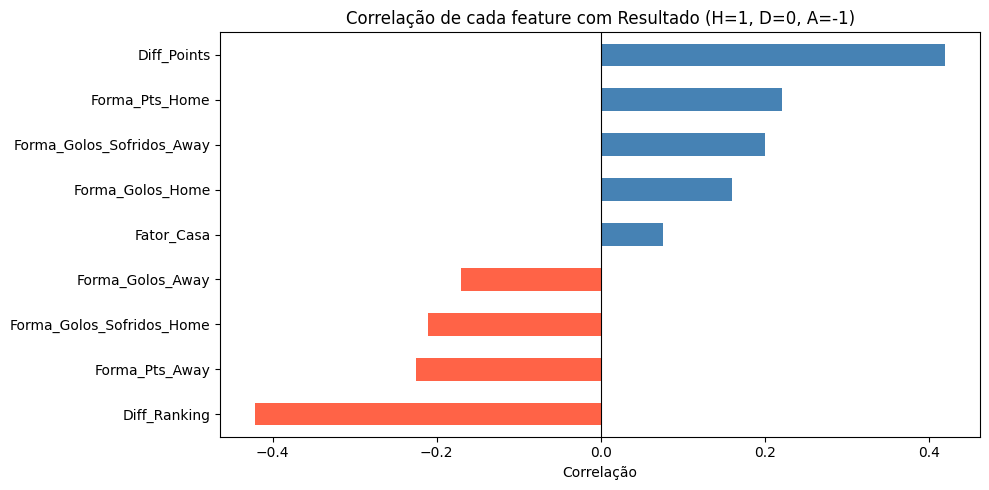

In [23]:
# --- 2. Correlação features vs resultado ---
df_corr = df_train.copy()
df_corr["Resultado_num"] = df_corr["Resultado"].map({"H": 1, "D": 0, "A": -1})
corr = df_corr[FEATURES_NUM + ["Resultado_num"]].corr()["Resultado_num"].drop("Resultado_num").sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
corr.plot(kind="barh", ax=ax, color=["tomato" if v < 0 else "steelblue" for v in corr])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de cada feature com Resultado (H=1, D=0, A=-1)")
ax.set_xlabel("Correlação")
plt.tight_layout()
plt.show()

Diff_Ranking é a correlação mais forte e negativa (-0.42) — quando home tem ranking pior (número maior), perde mais

Diff_Points é o inverso

Forma_Golos_Sofridos_Away tem correlação positiva forte (+0.20) — quando o adversário sofre muitos golos, home ganha mais. 

Feature nova V3 a funcionar
Forma_Pts_Home (+0.22) e Forma_Pts_Away (-0.22) simétricas — validam as features de forma

Fator_Casa (+0.08) — baixo mas positivo, consistente com o que já sabíamos

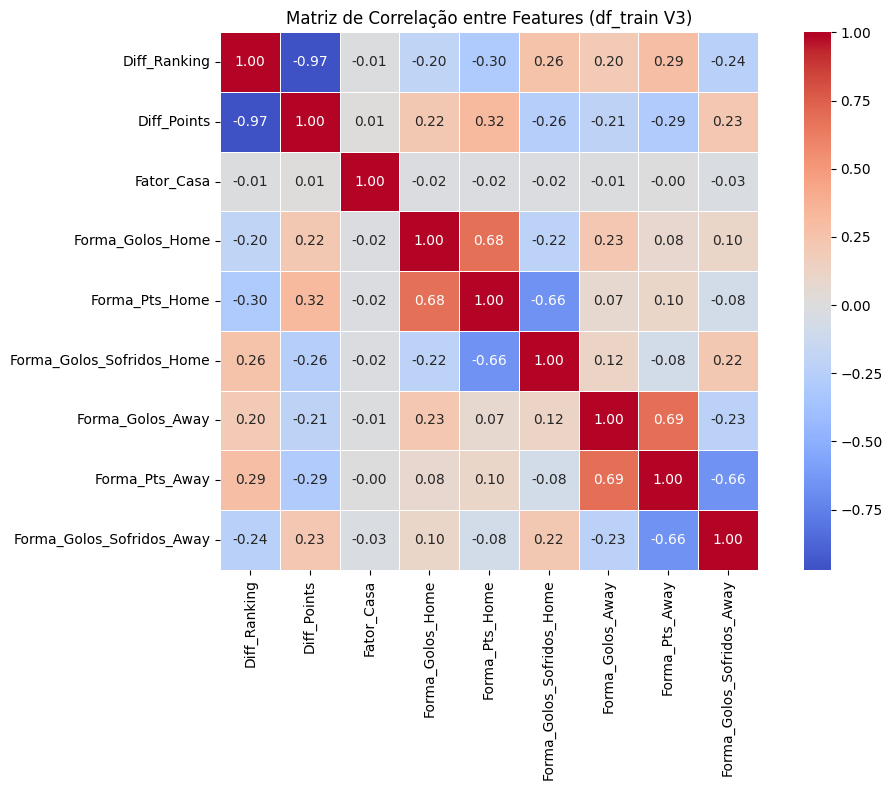

=== PARES COM CORRELAÇÃO ALTA (|r| > 0.6) ===
                feature_1      feature_2  correlacao
              Diff_Points   Diff_Ranking       -0.97
         Forma_Golos_Home Forma_Pts_Home        0.68
Forma_Golos_Sofridos_Home Forma_Pts_Home       -0.66
         Forma_Golos_Away Forma_Pts_Away        0.69
Forma_Golos_Sofridos_Away Forma_Pts_Away       -0.66


In [24]:
# --- Matriz de correlação entre features ---
fig, ax = plt.subplots(figsize=(11, 8))

corr_matrix = df_train[FEATURES_NUM].corr().round(2)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de Correlação entre Features (df_train V3)")
plt.tight_layout()
plt.show()

# Identificar pares com correlação alta (>0.6 ou <-0.6)
print("=== PARES COM CORRELAÇÃO ALTA (|r| > 0.6) ===")
corr_pairs = (
    corr_matrix.where(
        (corr_matrix.abs() > 0.6) & (corr_matrix != 1.0)
    )
    .stack()
    .dropna()  # ← adicionar isto
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlacao"]
corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]
if len(corr_pairs) == 0:
    print("Nenhum par com correlação > 0.6 — sem multicolinearidade relevante")
else:
    print(corr_pairs.to_string(index=False))

Correlações entre 0.66-0.69 — moderadas mas não críticas. 

Diff_Ranking vs Diff_Points correlação = -0.97:
São quase perfeitamente correlacionados (inversamente). Isto significa que têm essencialmente a mesma informação — quando o ranking sobe (número menor), os pontos sobem também. Ter os dois no modelo é redundância quase total.

Diff_Points tem correlação ligeiramente superior e é mais informativo — mas com -0.97 de correlação entre si, manter os dois vai criar multicolinearidade no modelo.

remover Diff_Ranking e manter apenas Diff_Points. O Diff_Points é estritamente superior:

Captura que Argentina (#1, 1902pts) está muito mais distante do Qatar (#57, 1220pts) do que o simples -56 de posições sugere
Escala contínua em vez de ordinal. Correlação mais forte com o resultado

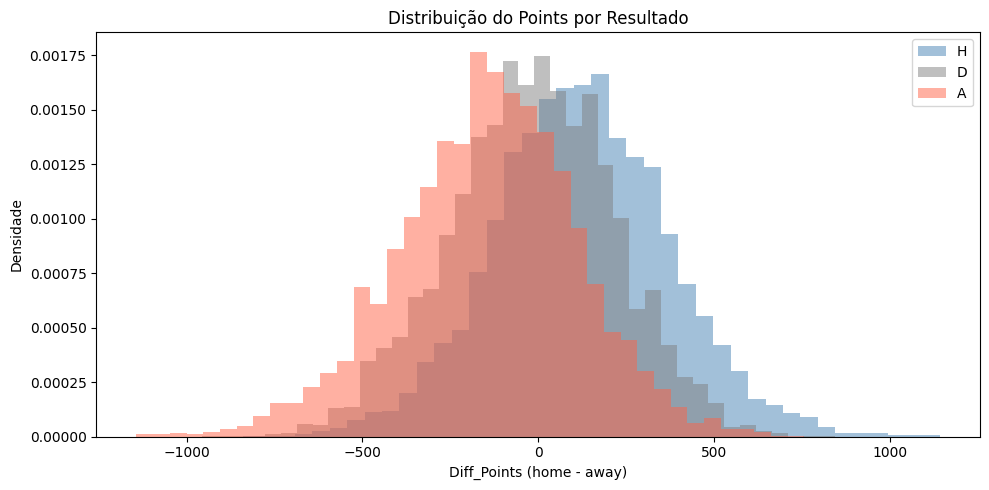

In [25]:
# --- 3. Distribuição do Diff_Ranking por resultado ---
fig, ax = plt.subplots(figsize=(10, 5))
for resultado, color in [("H", "steelblue"), ("D", "grey"), ("A", "tomato")]:
    subset = df_corr[df_corr["Resultado"] == resultado]["Diff_Points"]
    ax.hist(subset, bins=40, alpha=0.5, label=resultado, color=color, density=True)
ax.set_title("Distribuição do Points por Resultado")
ax.set_xlabel("Diff_Points (home - away)")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.show()

H (azul) deslocado para a esquerda — home ganha quando tem ranking melhor (número menor, logo Diff negativo)

A (vermelho) deslocado para a direita — away ganha quando tem ranking melhor

D (cinzento) centrado em zero — empates quando equipas equilibradas

Sobreposição enorme — confirma que o ranking sozinho não chega para separar as classes

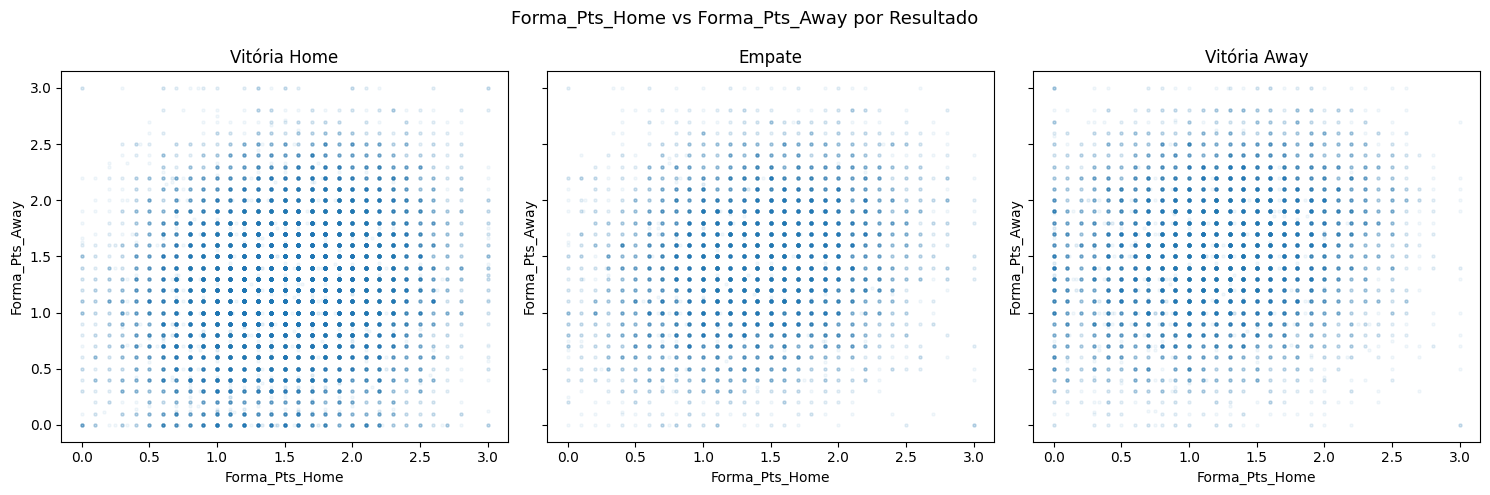

In [26]:
# --- 4. Forma_Pts_Home vs Forma_Pts_Away por resultado ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, (resultado, titulo) in enumerate([("H","Vitória Home"), ("D","Empate"), ("A","Vitória Away")]):
    subset = df_corr[df_corr["Resultado"] == resultado]
    axes[i].scatter(
        subset["Forma_Pts_Home"],
        subset["Forma_Pts_Away"],
        alpha=0.05, s=5
    )
    axes[i].set_title(titulo)
    axes[i].set_xlabel("Forma_Pts_Home")
    axes[i].set_ylabel("Forma_Pts_Away")
plt.suptitle("Forma_Pts_Home vs Forma_Pts_Away por Resultado", fontsize=13)
plt.tight_layout()
plt.show()

Os três painéis são visualmente muito semelhantes — Forma_Pts_Home vs Away não separa bem as classes visualmente
Sem fronteira de decisão clara — o modelo precisa de combinar várias features

In [27]:
# --- 5. Tipo_Competicao vs resultado ---
print("\n=== H/D/A POR TIPO_COMPETICAO (df_train) ===")
comp_result = (
    df_train.groupby("Tipo_Competicao")["Resultado"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .round(3)
)[["H", "D", "A"]]
comp_result["n_jogos"] = df_train.groupby("Tipo_Competicao")["Resultado"].count()
print(comp_result.sort_values("H", ascending=False).to_string())


=== H/D/A POR TIPO_COMPETICAO (df_train) ===
Resultado                H      D      A  n_jogos
Tipo_Competicao                                  
Qualificacao         0.516  0.210  0.274    15344
Amigavel             0.478  0.245  0.277    23277
Torneio_Continental  0.469  0.235  0.296     6000
Mundial              0.454  0.223  0.323      896


Confirma o padrão que vimos no notebook 02 — quanto mais competitivo o torneio, menor a vantagem home e maior a taxa de vitória away. O Mundial tem a distribuição mais equilibrada — e é exactamente o contexto que queremos prever.

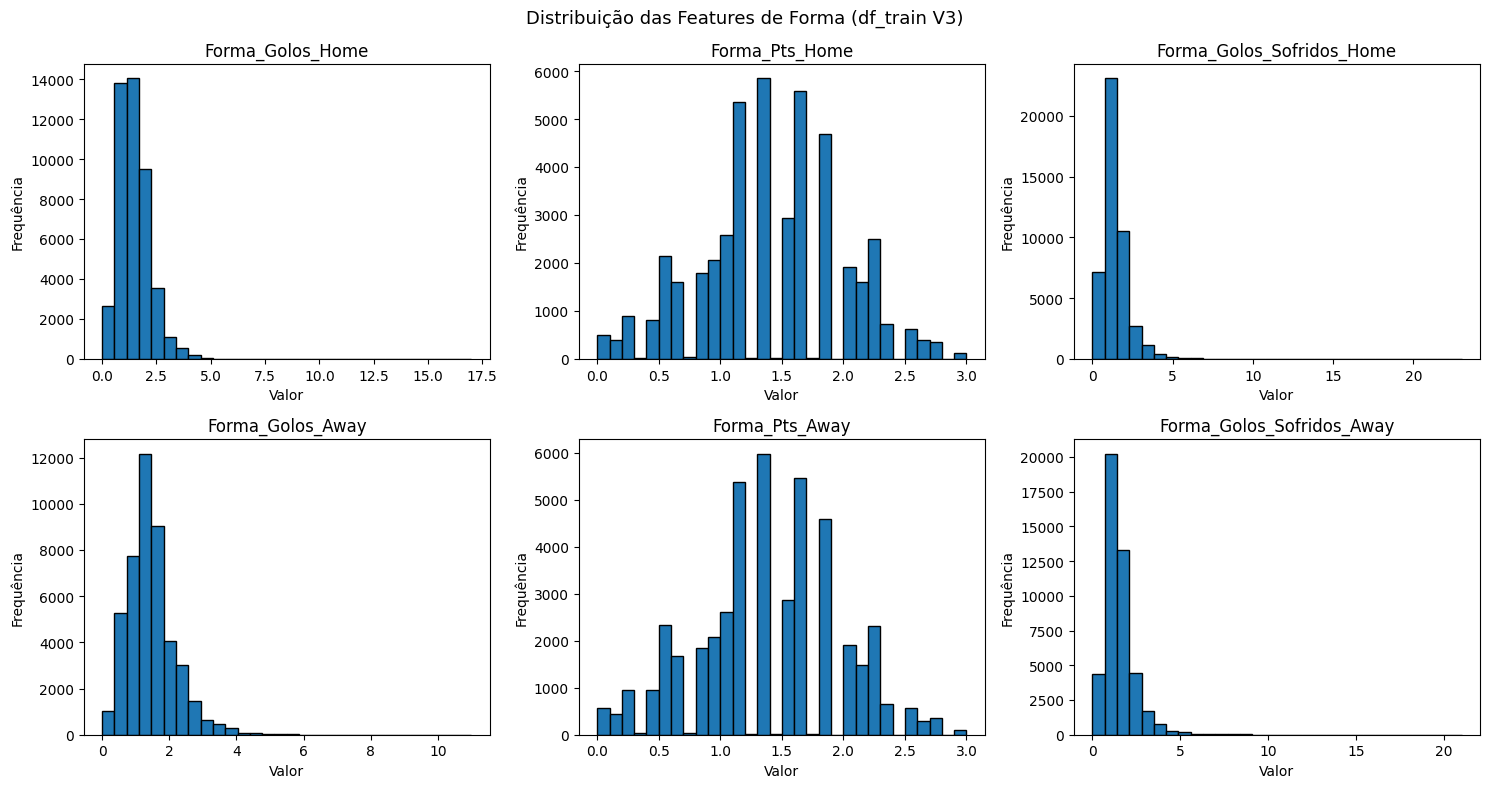

In [28]:
# --- 6. Distribuição das features de forma ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
forma_cols = [
    "Forma_Golos_Home", "Forma_Pts_Home", "Forma_Golos_Sofridos_Home",
    "Forma_Golos_Away", "Forma_Pts_Away", "Forma_Golos_Sofridos_Away",
]
for i, col in enumerate(forma_cols):
    axes[i].hist(df_train[col], bins=30, edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")
plt.suptitle("Distribuição das Features de Forma (df_train V3)", fontsize=13)
plt.tight_layout()
plt.show()

Forma_Golos_Sofridos tem outliers extremos (max 23 e 21) — o cap a 5.0 é aplicado no treino mas o df_train completo ainda os tem
Forma_Pts_Home e Away têm distribuição bimodal — equipas que ganham muito vs equipas que perdem muito
Forma_Golos com assimetria à direita — a maioria das equipas marca 1-2 golos de média

Diff_Points em vez de Diff_Ranking — a correlação do ranking é -0.42 mas usando pontos FIFA seria provavelmente mais forte porque captura a distância real entre equipas

Sample weight por tipo de competição — o Mundial representa apenas 5% do treino mas é 100% do teste. Dar mais peso a estes jogos no treino poderia reduzir o shift de distribuição

In [35]:
# --- Decisão: remover Diff_Ranking (correlação -0.97 com Diff_Points) ---
# Diff_Points é estritamente superior — captura distância real entre equipas
# Manter os dois seria multicolinearidade quasi-perfeita

FEATURES = [
    "Diff_Points",
    "Fator_Casa",
    "Tipo_Competicao",
    "Forma_Golos_Home",
    "Forma_Pts_Home",
    "Forma_Golos_Sofridos_Home",
    "Forma_Golos_Away",
    "Forma_Pts_Away",
    "Forma_Golos_Sofridos_Away",
]

df_train = df_train[["date", "home_team", "away_team",
                      "home_score", "away_score",
                      "tournament", "Resultado"] + FEATURES].copy()

print(f"Shape df_train final: {df_train.shape}")
print(f"Colunas: {df_train.columns.tolist()}")

df_train.to_csv("../data/df_train.csv", index=False)
print("Guardado: df_train.csv (sem Diff_Ranking)")

# Remover Diff_Ranking do df_wc_predict também
wc_predict_final = pd.read_csv("../data/df_wc_predict.csv")
wc_predict_final = wc_predict_final.drop(columns=["Diff_Ranking"], errors="ignore")
wc_predict_final.to_csv("../data/df_wc_predict.csv", index=False)
print(f"df_wc_predict actualizado: {wc_predict_final.columns.tolist()}")



Shape df_train final: (45517, 16)
Colunas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'Resultado', 'Diff_Points', 'Fator_Casa', 'Tipo_Competicao', 'Forma_Golos_Home', 'Forma_Pts_Home', 'Forma_Golos_Sofridos_Home', 'Forma_Golos_Away', 'Forma_Pts_Away', 'Forma_Golos_Sofridos_Away']
Guardado: df_train.csv (sem Diff_Ranking)
df_wc_predict actualizado: ['date', 'home_team', 'away_team', 'Forma_Golos_Home', 'Forma_Pts_Home', 'Forma_Golos_Sofridos_Home', 'Forma_Golos_Away', 'Forma_Pts_Away', 'Forma_Golos_Sofridos_Away', 'Diff_Points', 'Fator_Casa', 'Tipo_Competicao']
